<a href="https://colab.research.google.com/github/stephenkeyy77/ECON3916-Statistical-Machine-Learning/blob/main/Assignment%201/Econ_3916_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1.1: Construct the "Student Basket"

In [23]:
# Manual Data Construction
student_basket = [
    {'Item': 'Tuition', 'Price_2016': 45000, 'Price_2024': 58000},
    {'Item': 'Rent (1 Bed)', 'Price_2016': 1200, 'Price_2024': 1800},
    {'Item': 'Chipotle Burrito', 'Price_2016': 7.50, 'Price_2024': 11.50},
    {'Item': 'Spotify', 'Price_2016': 5, 'Price_2024': 7}
]

Step 1.2: Compute Inflation (Loops & Functions)

In [24]:
# Define the "Machine" (Function)
def calculate_inflation(base, current):
    return ((current - base) / base) * 100

# Run the Loop
for item in student_basket:
    rate = calculate_inflation(item['Price_2016'], item['Price_2024'])
    print(f"{item['Item']}: {rate:.2f}% Inflation")

Tuition: 28.89% Inflation
Rent (1 Bed): 50.00% Inflation
Chipotle Burrito: 53.33% Inflation
Spotify: 40.00% Inflation


Step 2.1: The "Data Proxy" Strategy

In [25]:
!pip install fredapi
from fredapi import Fred
fred = Fred(api_key='acedd82a4033eb0be34c43822d918d5f')

# Fetch Series
official_cpi = fred.get_series('CPIAUCSL')
tuition = fred.get_series('CUSR0000SEEB')
rent = fred.get_series('CUSR0000SEHA')
cable = fred.get_series('CUSR0000SERA02')
food_outside = fred.get_series('CUSR0000SEFV')



Step 2.2: Normalization Logic (CRITICAL)

In [26]:
import pandas as pd
# combine into a data frame
df_raw = pd.DataFrame({'Official CPI':official_cpi,'Tuition, Fees, & Childcare':tuition,'Rent of Primary Residence': rent,'Cable & Streaming TV':cable,'Food Away From Home': food_outside})

# set date index
df_raw.index = pd.to_datetime(df_raw.index)

# create a copy for further analyze
df = df_raw.copy()

#drop missing values
df = df.dropna()
start_date = '2016-01-01'
base_values = df.loc[start_date]


# reindex the value
df = df/base_values*100



Step 3.1: Visualizing Raw Components

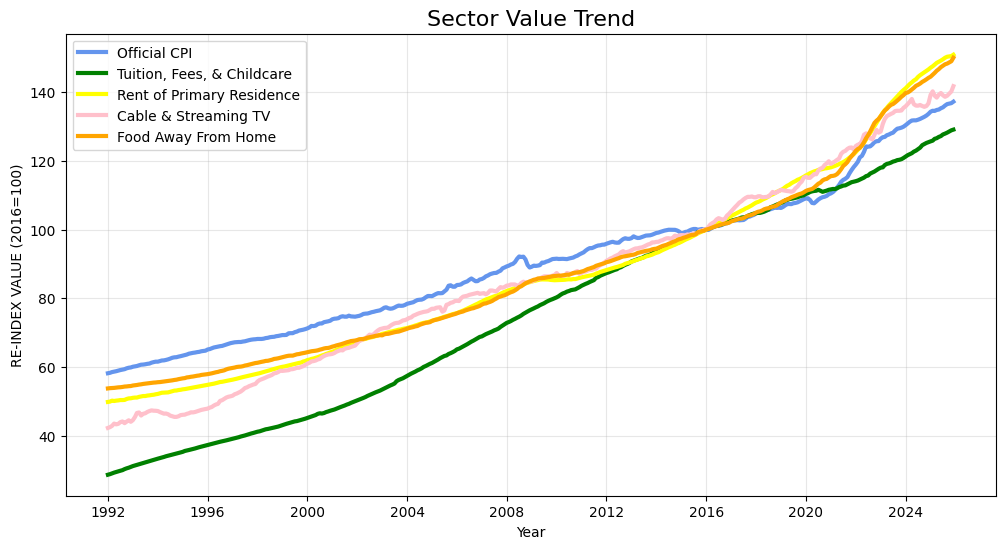

In [27]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Official CPI'], label='Official CPI', color='cornflowerblue', linewidth=3)
plt.plot(df.index, df['Tuition, Fees, & Childcare'], label='Tuition, Fees, & Childcare', color='green', linewidth=3)
plt.plot(df.index, df['Rent of Primary Residence'], label='Rent of Primary Residence', color='yellow', linewidth=3)
plt.plot(df.index, df['Cable & Streaming TV'], label='Cable & Streaming TV', color='pink', linewidth=3)
plt.plot(df.index, df['Food Away From Home'], label='Food Away From Home', color='orange', linewidth=3)

plt.title('Sector Value Trend', fontsize=16)
plt.ylabel('RE-INDEX VALUE (2016=100)')
plt.xlabel('Year')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Step 3.2: The Weighted "Student SPI" (Honest Chart)

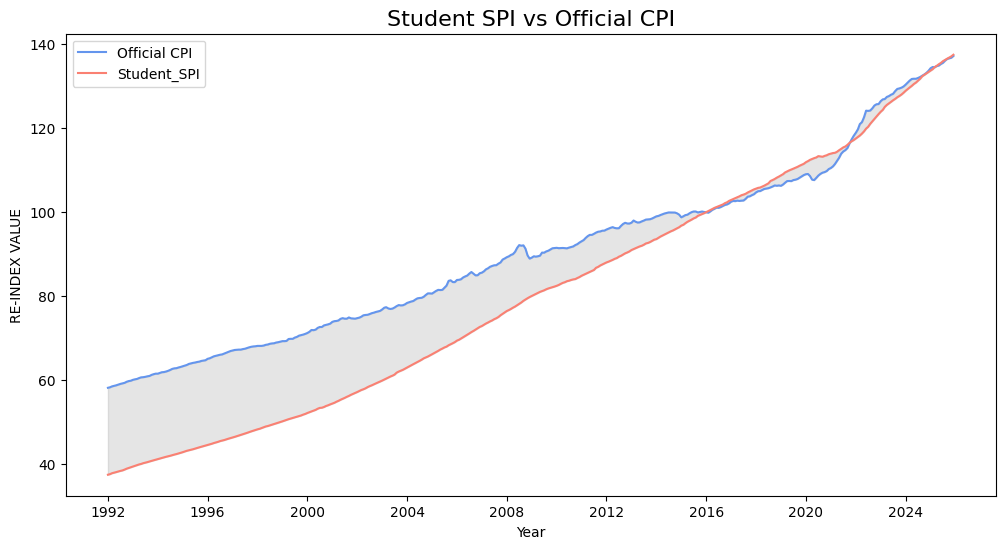

In [28]:
# set the rate
tuition_weight = 0.6
rent_weight = 0.25
food_outside_weight = 0.13
cable_weight = 0.02

# calculate student spi
df['Student_SPI'] = tuition_weight * df['Tuition, Fees, & Childcare'] + \
                      rent_weight * df['Rent of Primary Residence'] + \
                      food_outside_weight * df['Food Away From Home'] + \
                      cable_weight * df['Cable & Streaming TV']

# draw plot
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Official CPI'], color='cornflowerblue', label='Official CPI')
plt.plot(df.index, df['Student_SPI'], color='salmon', label='Student_SPI')
plt.fill_between(df.index,df['Official CPI'], df['Student_SPI'], color='gray', alpha=0.2)

plt.title('Student SPI vs Official CPI', fontsize=16)
plt.ylabel('RE-INDEX VALUE')
plt.xlabel('Year')
plt.legend()
plt.show()

Step 3.3: The Scale Fallacy (Why We Normalize)

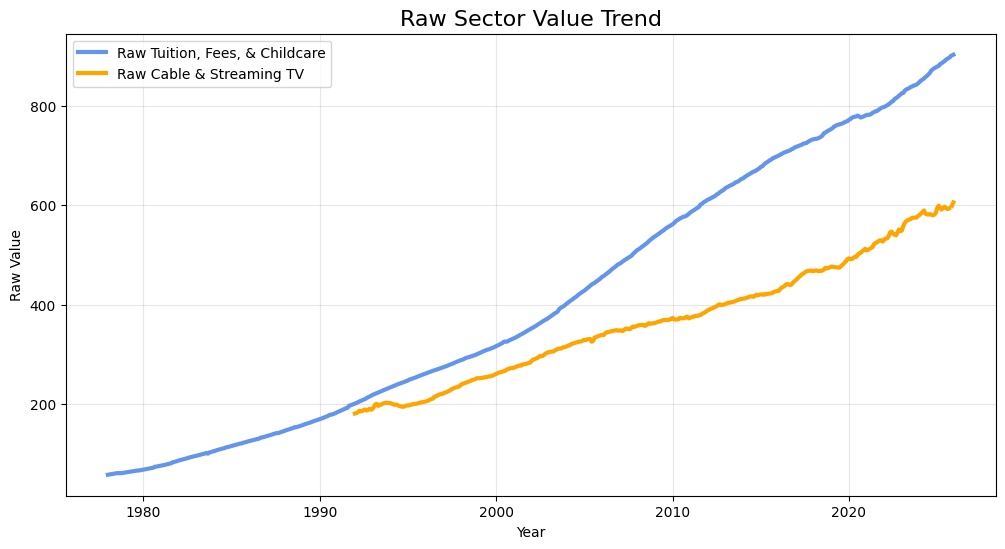

In [29]:
plt.figure(figsize=(12, 6))
plt.plot(df_raw.index, df_raw['Tuition, Fees, & Childcare'], color = 'cornflowerblue', label = 'Raw Tuition, Fees, & Childcare', linewidth = 3)
plt.plot(df_raw.index, df_raw['Cable & Streaming TV'], color = 'orange', label = 'Raw Cable & Streaming TV', linewidth = 3)
plt.title('Raw Sector Value Trend', fontsize=16)
plt.ylabel('Raw Value')
plt.xlabel('Year')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Answer for 3.3: Raw data indicates that tuition will be approximately 900 dollars by 2025, while cable and streaming services will cost around $600, suggesting tuition may see a larger increase.  However, these figures cannot be directly compared because they use different base years: the tuition index begins before 1980, while the cable and streaming index starts after 1990. Their differing starting points prevent effective inflation comparisons, as the baseline dates and prices vary. Therefore, before conducting any meaningful relative price growth comparison, both datasets must be adjusted to the same base year (e.g., 2016=100).

Task 4.1: The Ultimate Reality Check (Boston vs. USA vs. You)

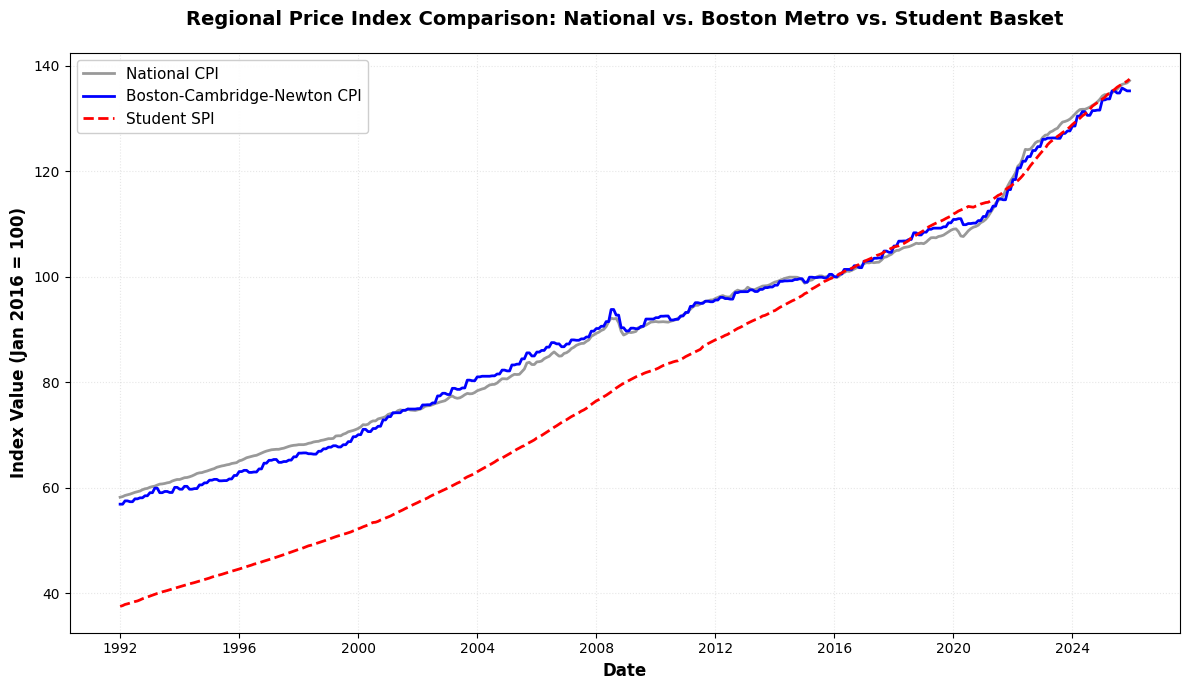


=== Regional Disparity Analysis ===
Latest National CPI: 137.19
Latest Boston CPI: 135.25
Latest Student SPI: 137.48

Boston vs National Gap: -1.93 points
Student vs National Gap: 0.29 points


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from fredapi import Fred

# Initialize FRED API (you'll need your API key)
fred = Fred(api_key='acedd82a4033eb0be34c43822d918d5f')

# Fetch Boston-Cambridge-Newton CPI data
boston_cpi_raw = fred.get_series('CUURA103SA0')

# Convert to DataFrame for easier manipulation
boston_df = pd.DataFrame({
    'Boston_CPI_Raw': boston_cpi_raw
})

# Re-index to Jan 1, 2016 = 100
base_date = '2016-01-01'
base_value = boston_df.loc[base_date, 'Boston_CPI_Raw']
boston_df['Boston_CPI'] = (boston_df['Boston_CPI_Raw'] / base_value) * 100

# Add Boston_CPI to the main DataFrame 'df' using direct assignment
df['Boston_CPI'] = boston_df['Boston_CPI']

# Handle missing values if data frequencies don't align
# Forward-fill for monthly data gaps
df['Boston_CPI'] = df['Boston_CPI'].ffill()

# Create the comparative visualization
plt.figure(figsize=(12, 7))

# Plot all three series
plt.plot(df.index, df['Official CPI'],
         color='grey', linewidth=2, label='National CPI', alpha=0.8)
plt.plot(df.index, df['Boston_CPI'],
         color='blue', linewidth=2, label='Boston-Cambridge-Newton CPI')
plt.plot(df.index, df['Student_SPI'],
         color='red', linewidth=2, label='Student SPI', linestyle='--')

# Formatting for professional presentation
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('Index Value (Jan 2016 = 100)', fontsize=12, fontweight='bold')
plt.title('Regional Price Index Comparison: National vs. Boston Metro vs. Student Basket',
          fontsize=14, fontweight='bold', pad=20)
plt.legend(loc='best', fontsize=11, framealpha=0.95)
plt.grid(True, alpha=0.3, linestyle=':')
plt.tight_layout()

plt.show()

# Optional: Print summary statistics for regional disparity analysis
print("\n=== Regional Disparity Analysis ===")
print(f"Latest National CPI: {df['Official CPI'].iloc[-1]:.2f}")
print(f"Latest Boston CPI: {df['Boston_CPI'].iloc[-1]:.2f}")
print(f"Latest Student SPI: {df['Student_SPI'].iloc[-1]:.2f}")
print(f"\nBoston vs National Gap: {(df['Boston_CPI'].iloc[-1] - df['Official CPI'].iloc[-1]):.2f} points")
print(f"Student vs National Gap: {(df['Student_SPI'].iloc[-1] - df['Official CPI'].iloc[-1]):.2f} points")

My Github link: https://github.com/stephenkeyy77/ECON3916-Statistical-Machine-Learning/tree/main/Assignment%201